In [19]:
#Analysis of Appointments Dataset

#Import pacakges
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

df = pd.read_csv("/Users/saadana/Downloads/appointments_cleaned.csv")

In [21]:
#Confirming data is clean 

#Check data's dimensions, structure, and type
print(df.shape)
print(df.info())
print(df.describe())

#Check missing values
print(df.isnull().sum()) #no missing values were found
df = df.drop_duplicates() #remove duplicated rows 
print(df.duplicated().sum()) #no duplicated rows were found 

appointment_id         0
patient_id             0
provider_id            0
department_id          0
scheduled_date         0
appointment_date       0
visit_type             0
wait_days              0
status                 0
future_no_show_flag    0
dtype: int64
0


In [18]:
#Analysis 

#Summarize wait days data 
print(df['wait_days'].describe())

count    979302.000000
mean         23.354882
std          14.612455
min           0.000000
25%          11.000000
50%          23.000000
75%          35.000000
max          73.000000
Name: wait_days, dtype: float64


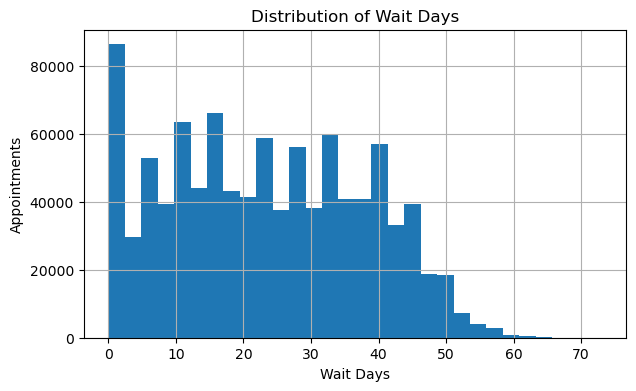

In [25]:
#Create histogram of wait days 

#Create blank figure 
plt.figure(figsize=(7,4))

#Create a histogram of wait days by appointments
df['wait_days'].hist(bins=30)

#Add titles
plt.title('Distribution of Wait Days')
plt.xlabel('Wait Days')
plt.ylabel('Appointments')
plt.show()

In [104]:
#Find average wait time by visit

avg_wait = df.groupby("visit_type")['wait_days'].mean().sort_values(ascending=False).round(2)
print(avg_wait)

visit_type
Procedure      23.42
Virtual        23.38
New Consult    23.36
Follow-up      23.34
Urgent         23.23
Name: wait_days, dtype: float64


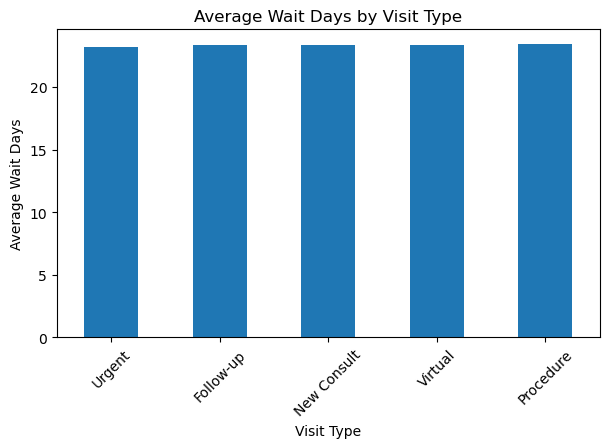

In [29]:
#Create a barplot of wait time by visit 

#Create blank figure 
plt.figure(figsize=(7,4))

#Create a barplot of average wait time by visit time 
avg_wait.plot(kind='bar')

#Add titles 
plt.title('Average Wait Days by Visit Type')
plt.xlabel('Visit Type')
plt.xticks(rotation=45)
plt.ylabel('Average Wait Days')
plt.show()

In [38]:
#Find median wait time

median_wait = df.groupby('visit_type')['wait_days'].median().sort_values(ascending=False)
print(median_wait)



visit_type
Follow-up      23.0
New Consult    23.0
Procedure      23.0
Virtual        23.0
Urgent         22.0
Name: wait_days, dtype: float64


<Figure size 700x500 with 0 Axes>

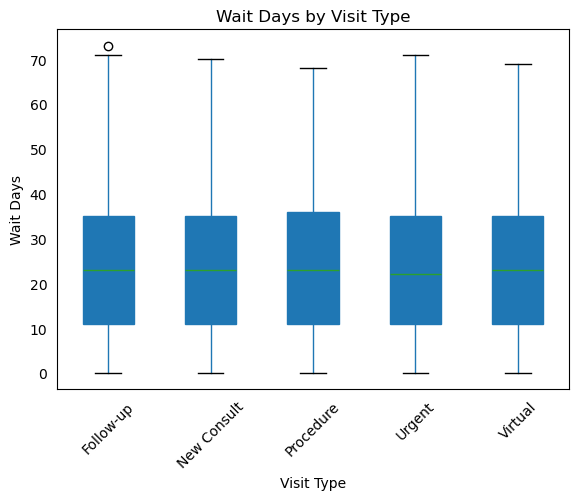

In [44]:
#Create boxplot of wait days by visit type 

plt.figure(figsize=(7,5))

#Create a boxplot of wait days by visit type  
ax = df.boxplot(column='wait_days',by='visit_type',rot=45, patch_artist = True)

#Remove grid and ticks from graph 
ax.grid(False)
ax.tick_params(bottom=False, left=False)

#Add titles 
plt.title('Wait Days by Visit Type')
plt.suptitle("")
plt.xlabel('Visit Type')
plt.ylabel('Wait Days')
plt.show()

In [45]:
#Find status of appointments 

status = df['status'].value_counts()
print(status)

status
Completed      758228
No Show        111244
Cancelled       69750
Rescheduled     40080
Name: count, dtype: int64


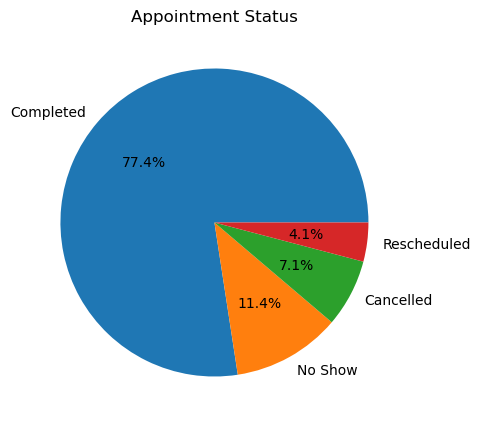

In [52]:
#Create a pie chart of appointment status

#Create blank figure 
plt.figure(figsize=(7,5))

#Create a pie chart of appointment status 
plt.pie(status,labels=status.index,autopct='%1.1f%%')

#Add titles 
plt.title('Appointment Status')
plt.show()

In [108]:
#Find no show rate by visit 

table = pd.crosstab(df['status'],df['visit_type'],normalize='index').round(4)*100
print(table)


visit_type   Follow-up  New Consult  Procedure  Urgent  Virtual
status                                                         
Cancelled        46.72        17.43      13.33    7.03    15.50
Completed        47.01        17.43      13.24    7.11    15.21
No Show          38.93        22.46      11.07    5.95    21.59
Rescheduled      47.44        17.27      13.27    6.85    15.18


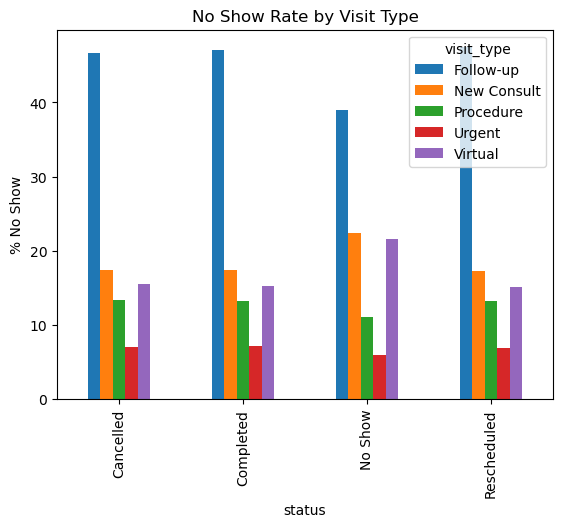

In [65]:
#Create a barplot of appointment status by visit type 

table.plot(kind="bar")
plt.ylabel("% No Show")
plt.title("No Show Rate by Visit Type")
plt.show()

In [99]:
#Find appointment volume by department 

visit_counts = df["visit_type"].value_counts()
print(visit_counts)



visit_type
Follow-up      451388
New Consult    176204
Virtual        156250
Procedure      127287
Urgent          68173
Name: count, dtype: int64


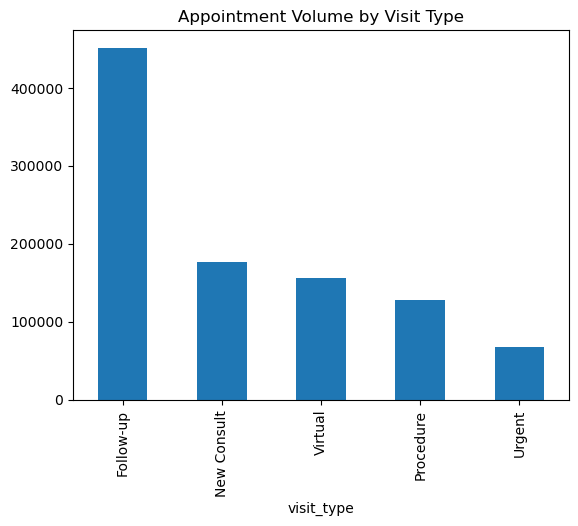

In [98]:
#Create barplot of number of appointments by visit type 

visit_counts.plot(kind="bar")
plt.title("Appointment Volume by Visit Type")
plt.show()

In [103]:
#Find monthly appointment volume 

#Ensure appointment dates are converted to date format 

df["appointment_date"] = pd.to_datetime(df["appointment_date"])

#Create 'months' column from dates 
df["Month"] = df["appointment_date"].dt.to_period("M")
monthly = df.groupby("Month").size()

print(monthly)
print(f"Peak Month:{monthly.idxmax()}({monthly.max()} appointments)")
print(f"Lowest Month:{monthly.idxmin()}({monthly.min()} appointments)")

Month
2023-01    27727
2023-02    25129
2023-03    27913
2023-04    26714
2023-05    27939
2023-06    26712
2023-07    27917
2023-08    27566
2023-09    26679
2023-10    27925
2023-11    26617
2023-12    27757
2024-01    27540
2024-02    26026
2024-03    27722
2024-04    26814
2024-05    27594
2024-06    26708
2024-07    27723
2024-08    27945
2024-09    26586
2024-10    27610
2024-11    26908
2024-12    27550
2025-01    27954
2025-02    24926
2025-03    27537
2025-04    26587
2025-05    27918
2025-06    26962
2025-07    27755
2025-08    27678
2025-09    26820
2025-10    27501
2025-11    26625
2025-12    27718
Freq: M, dtype: int64
Peak Month:2025-01(27954 appointments)
Lowest Month:2025-02(24926 appointments)


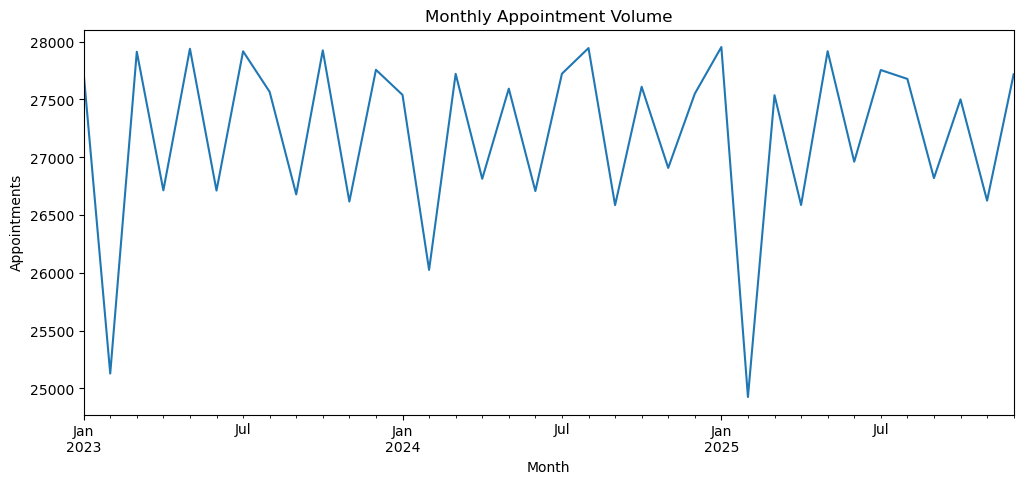

In [102]:
#Create a line plot of appointments by months 
monthly.plot(figsize=(12,5))
plt.ylabel("Appointments")
plt.title("Monthly Appointment Volume")

plt.show()

In [97]:
# Create a summary chart grouped by visit type
summary = df.groupby("visit_type").agg(
    **{"Appointment Volume": ("appointment_id", "count"),
       "Average Wait Days": ("wait_days", "mean"),
       "No Show Rate (%)": ("future_no_show_flag", "mean")}
)

# Convert the no show rate to a percentage 
summary["No Show Rate (%)"] = round(summary["No Show Rate (%)"] * 100, 2)
summary["Average Wait Days"] = round(summary["Average Wait Days"], 2)

# Sort by the most appointment volume
summary.sort_values(by="Appointment Volume", ascending=False)


,Appointment Volume,Average Wait Days,No Show Rate (%)
visit_type,,,
Follow-up,451388,23.34,9.60
New Consult,176204,23.36,14.18
Virtual,156250,23.38,15.37
Procedure,127287,23.42,9.67
Urgent,68173,23.23,9.70
